In [14]:
!pip install matplotlib deap

In [15]:
import random
import matplotlib.pyplot as plt
import numpy as np
from deap import base, creator, tools, algorithms

In [16]:
def generate(n):# generating 10 random co-ordinates(location of the delivery address)
  ans=[]
  for _ in range(n):
    x=random.randint(0,100)
    y=random.randint(0,100)
    ans.append((x,y))
  return ans
num_locations=10
locations= generate(num_locations)
depot=(40,40)
num_vehicles=3

In [23]:
creator.create("FitnessMin",base.Fitness, weights =(-1.0,-1.0))
creator.create("Individual",list,fitness=creator.FitnessMin)
toolbox= base.Toolbox()
toolbox.register("indices",random.sample,range(num_locations),num_locations)
toolbox.register("individual",tools.initIterate,creator.Individual,toolbox.indices)
toolbox.register("population",tools.initRepeat,list,toolbox.individual)


In [24]:
def f(individual):
  total_distance = 0
  distances = []

  for i in range(num_vehicles):
      vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]

      vehicle_distance = sum(np.linalg.norm(np.array(vehicle_route[k+1]) - np.array(vehicle_route[k])) for k in range(len(vehicle_route)-1))
      total_distance += vehicle_distance
      distances.append(vehicle_distance)
  balance_penalty = np.std(distances)
  return total_distance, balance_penalty

In [25]:
toolbox.register("evaluate", f)
toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)


In [26]:
def plot_routes(individual, title="Routes"):
    plt.figure()
    # Plot locations as blue dots and the depot as a red square
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    # Draw routes for each vehicle
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        plt.plot(*zip(*vehicle_route), '-')

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.show()


In [31]:
def main():
    # random.seed(42)  # Seed for reproducibility
    pop = toolbox.population(n=300)  # Generate initial population
    hof = tools.HallOfFame(1)  # Hall of Fame to store the best individual

    # Setup statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    # Run the genetic algorithm
    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    # Plot the best route found
    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof


gen	nevals	avg    	min    
0  	300   	354.086	2.73279
1  	227   	344.119	3.02933
2  	226   	332.97 	4.15433
3  	224   	328.195	2.28135
4  	227   	323.128	3.65639
5  	236   	321.061	3.66398
6  	230   	321.609	3.66398
7  	222   	319.258	2.2471 
8  	219   	311.2  	1.80813
9  	217   	299.659	2.2471 
10 	245   	300.688	1.94542
11 	213   	289.384	1.30208
12 	218   	275.656	1.30208
13 	223   	262.666	1.30208
14 	233   	258.493	1.30208
15 	232   	245.141	1.30208
16 	241   	241.587	2.67847
17 	242   	236.507	4.90172
18 	214   	227.333	1.30208
19 	220   	232.047	8.97939
20 	239   	229.121	9.93731
21 	207   	226.457	5.05477
22 	228   	227.077	1.19872
23 	229   	224.622	6.23796
24 	235   	223.809	1.19872
25 	228   	223.642	9.73571
26 	226   	224.39 	11.0334
27 	218   	225.389	1.19872
28 	225   	226.672	1.19872
29 	224   	225.714	5.05477
30 	222   	224.609	5.05477
31 	224   	223.519	9.73571
32 	217   	225.879	6.23796
33 	210   	225.169	1.19872
34 	216   	224.354	5.05477
35 	220   	225.006	11.0334
3

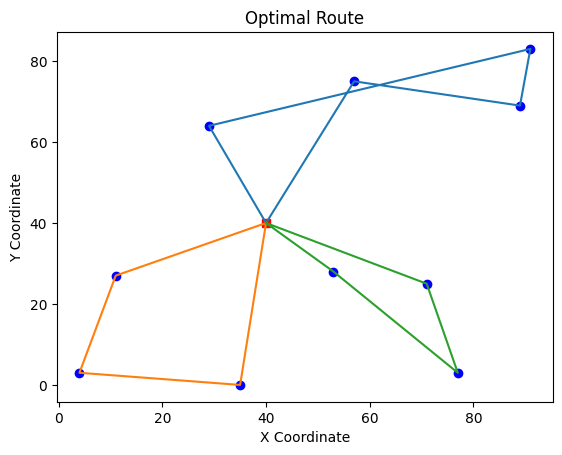

([[9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 6, 0, 3, 5, 1, 7, 8, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 6, 0, 3, 5, 1, 7, 8, 2],
  [9, 4, 6, 0, 3, 5, 1, 7, 8, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 1, 8, 0, 3, 5, 4, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 6, 0, 3, 2, 1, 7, 8, 5],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 6, 0, 3, 5, 1, 7, 8, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 6, 5, 1, 7, 3, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 6, 0, 3, 5, 1, 7, 8, 2],
  [9, 4, 8, 0, 3, 5, 1, 7, 6, 2],
  [9, 4, 8, 0,

In [32]:
main()